# Asymmetric Clausius at Finite Temperature: Fixed-$y$ Critical Branches


In [1]:
from dataclasses import replace
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

repo_root = Path("/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows")
results_dir = repo_root / "results"
results_dir.mkdir(parents=True, exist_ok=True)

asym_src = repo_root / "asymmetric_clausius_fit" / "src"
ground_src = repo_root / "ground_state_ab_k0" / "src"
quantum_src = repo_root / "quantum_tc_nc_scf" / "src"

for path in [str(asym_src), str(ground_src), str(quantum_src)]:
    if path not in sys.path:
        sys.path.insert(0, path)

from asymmetric_clausius_fit.finite_temperature import compute_fixed_y_family_from_fit_df
from quantum_tc_nc_scf import QuantumCriticalSettings, compute_quantum_critical_point

pd.set_option("display.precision", 6)

output_dir = results_dir / "asymmetric_clausius_finite_temperature_fixed_y"
output_dir.mkdir(parents=True, exist_ok=True)

ACTIVE_TARGET_K0S = [250.0, 260.0, 270.0, 280.0, 290.0, 300.0, 310.0, 315.0]
Y_VALUES = [0.5, 0.4, 0.3, 0.2, 0.1, 0.000000001, 0.0]

# Broader window than the symmetric notebook because the critical branch moves to lower T and n as y decreases.
SETTINGS = replace(
    QuantumCriticalSettings.quick(),
    t_min_cp=4.0,
    t_max_cp=22.0,
    n_min_cp=0.020,
    n_max_cp=0.075,
    coarse_t_count=15,
    coarse_n_count=15,
    outer_max_iter=30,
)

output_dir


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_finite_temperature_fixed_y')

For each fixed $y$, the finite-temperature extension used here is:

\begin{align}
n_p &= y n, \\
n_n &= (1-y)n,
\end{align}

\begin{align}
x_p &= b_n n_p + b_{pn} n_n, & f_p &= 1 - x_p, \\
x_n &= b_{pn} n_p + b_n n_n, & f_n &= 1 - x_n,
\end{align}

\begin{align}
n_p^{\mathrm{id}}(T,\mu_p^*) &= \frac{n_p}{f_p}, \\
n_n^{\mathrm{id}}(T,\mu_n^*) &= \frac{n_n}{f_n},
\end{align}

and the pressure branch is evaluated as

\begin{equation}
P(T,n;y) = p_p^{\mathrm{id}}(T,\mu_p^*) + p_n^{\mathrm{id}}(T,\mu_n^*) - \frac{C(y)n^2}{(1+cn)^2},
\end{equation}

with

\begin{equation}
C(y)=a_n\left[y^2+(1-y)^2\right]+2a_{pn}y(1-y).
\end{equation}

At $y=0.5$, this reduces numerically to the symmetric Clausius solver.

In [2]:
fit_csv = results_dir / "asymmetric_clausius_fit_results.csv"
fit_df = pd.read_csv(fit_csv)
fit_df = fit_df[fit_df["target_k0"].isin(ACTIVE_TARGET_K0S)].copy()
fit_df = fit_df.sort_values("target_k0").reset_index(drop=True)

display(fit_df[["target_k0", "K0", "c", "a_avg", "b_avg", "a_n", "a_pn", "b_n", "b_pn"]])


,target_k0,K0,c,a_avg,b_avg,a_n,a_pn,b_n,b_pn
0,250.0,250.000002,4.735853,472.327508,1.727371,259.413733,685.241282,1.316923,2.137819
1,260.0,260.000001,4.516312,466.026019,1.800838,256.197399,675.854639,1.351272,2.250404
2,270.0,269.999999,4.309453,460.064473,1.870418,253.177802,666.951144,1.384757,2.356079
3,280.0,280.000000,4.114108,454.412697,1.936450,250.336526,658.488869,1.417423,2.455476
4,290.0,290.000001,3.929255,449.044178,1.999231,247.657454,650.430902,1.449313,2.549149
5,300.0,300.000001,3.753994,443.935490,2.059026,245.126408,642.744572,1.480464,2.637588
6,310.0,310.000001,3.587529,439.065850,2.116069,242.730858,635.400842,1.510911,2.721226
7,315.0,314.999999,3.507371,436.714809,2.143624,241.580371,631.849247,1.525881,2.761368


In [3]:
fixed_y_results = compute_fixed_y_family_from_fit_df(fit_df, Y_VALUES, settings=SETTINGS)
fixed_y_df = pd.DataFrame([result.__dict__ for result in fixed_y_results])
status_rows = []
for target_k0 in ACTIVE_TARGET_K0S:
    for y in Y_VALUES:
        has_solution = ((fixed_y_df["target_k0"] == float(target_k0)) & (fixed_y_df["y"] == float(y))).any()
        status_rows.append(
            {
                "target_k0": float(target_k0),
                "y": float(y),
                "status": "converged" if has_solution else "no_solution_in_window",
            }
        )
status_df = pd.DataFrame(status_rows)

fixed_y_csv = output_dir / "asymmetric_clausius_fixed_y_tc_nc.csv"
status_csv = output_dir / "asymmetric_clausius_fixed_y_branch_status.csv"
fixed_y_df.to_csv(fixed_y_csv, index=False)
status_df.to_csv(status_csv, index=False)

display(fixed_y_df[["target_k0", "y", "Tc", "nc", "Pc", "score", "iterations"]])
display(status_df)
fixed_y_csv


,target_k0,y,Tc,nc,Pc,score,iterations
0,250.0,0.5,16.163322,0.049925,0.241953,2.392122e-14,12
1,250.0,0.4,15.574217,0.049174,0.229993,9.928385e-14,11
2,250.0,0.3,13.753715,0.046649,0.193697,2.429605e-14,12
3,250.0,0.2,10.505401,0.041313,0.132452,3.999588e-14,12
4,250.0,0.1,5.139331,0.029874,0.047953,5.689756e-14,14
5,260.0,0.5,16.272525,0.050667,0.248700,1.205140e-13,11
6,260.0,0.4,15.683303,0.049929,0.236540,8.000621e-14,11
7,260.0,0.3,13.859511,0.047436,0.199534,8.015320e-14,11
8,260.0,0.2,10.593920,0.042109,0.136732,5.661272e-14,10
9,260.0,0.1,5.161937,0.030507,0.049331,3.727513e-14,12


,target_k0,y,status
0,250.0,5.000000e-01,converged
1,250.0,4.000000e-01,converged
2,250.0,3.000000e-01,converged
3,250.0,2.000000e-01,converged
4,250.0,1.000000e-01,converged
5,250.0,1.000000e-09,no_solution_in_window
6,250.0,0.000000e+00,no_solution_in_window
7,260.0,5.000000e-01,converged
8,260.0,4.000000e-01,converged
9,260.0,3.000000e-01,converged


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_finite_temperature_fixed_y/asymmetric_clausius_fixed_y_tc_nc.csv')

In [4]:
symmetry_check_rows = []
for row in fit_df.itertuples(index=False):
    sym_result = compute_quantum_critical_point("clausius", par=float(row.c), settings=SETTINGS)
    fixed_y_row = fixed_y_df[(fixed_y_df["target_k0"] == float(row.target_k0)) & (fixed_y_df["y"] == 0.5)]
    if sym_result is None or fixed_y_row.empty:
        continue
    fixed_y_row = fixed_y_row.iloc[0]
    symmetry_check_rows.append(
        {
            "target_k0": float(row.target_k0),
            "Tc_fixed_y_0p5": float(fixed_y_row.Tc),
            "Tc_symmetric": float(sym_result.Tc),
            "dTc": float(fixed_y_row.Tc - sym_result.Tc),
            "nc_fixed_y_0p5": float(fixed_y_row.nc),
            "nc_symmetric": float(sym_result.nc),
            "dnc": float(fixed_y_row.nc - sym_result.nc),
            "Pc_fixed_y_0p5": float(fixed_y_row.Pc),
            "Pc_symmetric": float(sym_result.Pc),
            "dPc": float(fixed_y_row.Pc - sym_result.Pc),
        }
    )

symmetry_check_df = pd.DataFrame(symmetry_check_rows)
symmetry_check_csv = output_dir / "asymmetric_clausius_fixed_y_symmetry_check.csv"
symmetry_check_df.to_csv(symmetry_check_csv, index=False)
display(symmetry_check_df)
symmetry_check_csv


,target_k0,Tc_fixed_y_0p5,Tc_symmetric,dTc,nc_fixed_y_0p5,nc_symmetric,dnc,Pc_fixed_y_0p5,Pc_symmetric,dPc
0,250.0,16.163322,16.163330,-0.000008,0.049925,0.049925,-1.244026e-08,0.241953,0.241953,-1.953949e-07
1,260.0,16.272525,16.272519,0.000006,0.050667,0.050667,4.015382e-09,0.248700,0.248700,5.250905e-07
2,270.0,16.378588,16.378582,0.000005,0.051385,0.051385,-5.682375e-09,0.255368,0.255367,4.840880e-07
3,280.0,16.481717,16.481715,0.000001,0.052081,0.052081,-5.849274e-09,0.261960,0.261959,2.740793e-07
4,290.0,16.582093,16.582092,0.000001,0.052757,0.052757,-5.772393e-09,0.268479,0.268479,2.772849e-07
5,300.0,16.679885,16.679884,0.000001,0.053413,0.053413,-5.730153e-09,0.274930,0.274930,2.804319e-07
6,310.0,16.775239,16.775238,0.000001,0.054051,0.054051,-5.693003e-09,0.281315,0.281315,2.835234e-07
7,315.0,16.822045,16.822044,0.000001,0.054364,0.054364,-5.654305e-09,0.284484,0.284483,2.850650e-07


PosixPath('/Users/dajuarez4/Documents/QuarkMatt/nuclear_matter_workflows/results/asymmetric_clausius_finite_temperature_fixed_y/asymmetric_clausius_fixed_y_symmetry_check.csv')

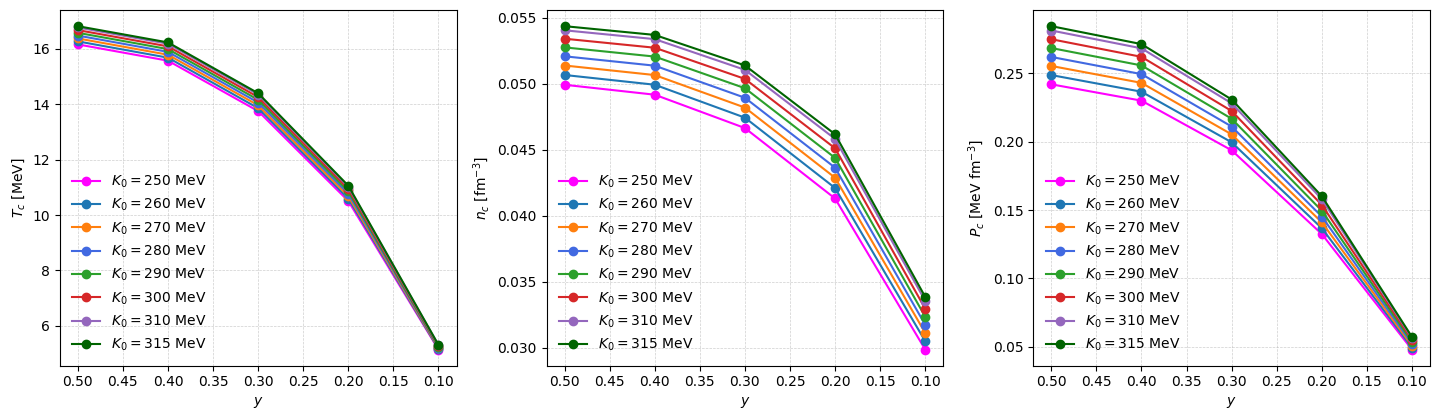

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.3), sharex=True)
color_map = {250.0: "magenta", 280.0: "royalblue", 315.0: "darkgreen"}

for target_k0, group in fixed_y_df.groupby("target_k0"):
    group = group.sort_values("y", ascending=False)
    color = color_map.get(float(target_k0), None)
    label = rf"$K_0={int(round(float(target_k0)))}$ MeV"
    axes[0].plot(group["y"], group["Tc"], marker="o", color=color, label=label)
    axes[1].plot(group["y"], group["nc"], marker="o", color=color, label=label)
    axes[2].plot(group["y"], group["Pc"], marker="o", color=color, label=label)

axes[0].set_ylabel(r"$T_c$ [MeV]")
axes[1].set_ylabel(r"$n_c$ [fm$^{-3}$]")
axes[2].set_ylabel(r"$P_c$ [MeV fm$^{-3}$]")

for ax in axes:
    ax.set_xlabel(r"$y$")
    ax.grid(True, ls="--", lw=0.5, alpha=0.6)
    ax.legend(frameon=False)
    ax.invert_xaxis()

plt.tight_layout()
plt.show()


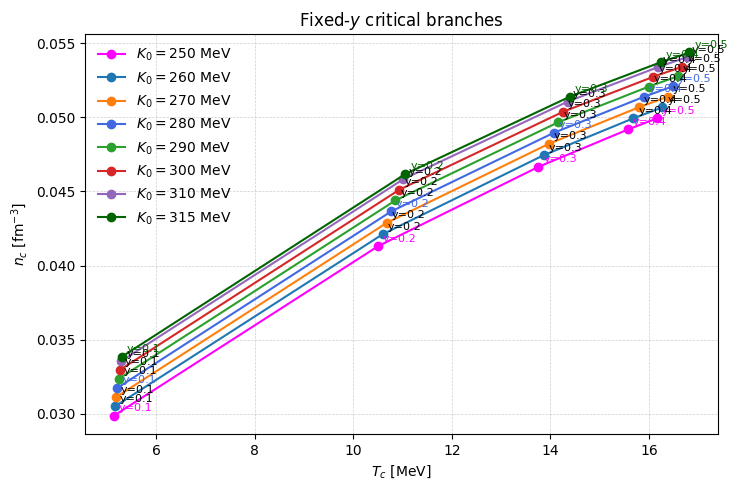

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))

for target_k0, group in fixed_y_df.groupby("target_k0"):
    group = group.sort_values("Tc")
    color = color_map.get(float(target_k0), None)
    label = rf"$K_0={int(round(float(target_k0)))}$ MeV"
    ax.plot(group["Tc"], group["nc"], marker="o", color=color, label=label)
    for _, row in group.iterrows():
        ax.text(row["Tc"] + 0.10, row["nc"] + 0.0003, f"y={row['y']:.1f}", color=color, fontsize=8)

ax.set_xlabel(r"$T_c$ [MeV]")
ax.set_ylabel(r"$n_c$ [fm$^{-3}$]")
ax.set_title("Fixed-$y$ critical branches")
ax.grid(True, ls="--", lw=0.5, alpha=0.6)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
